自动求导的两种模式：

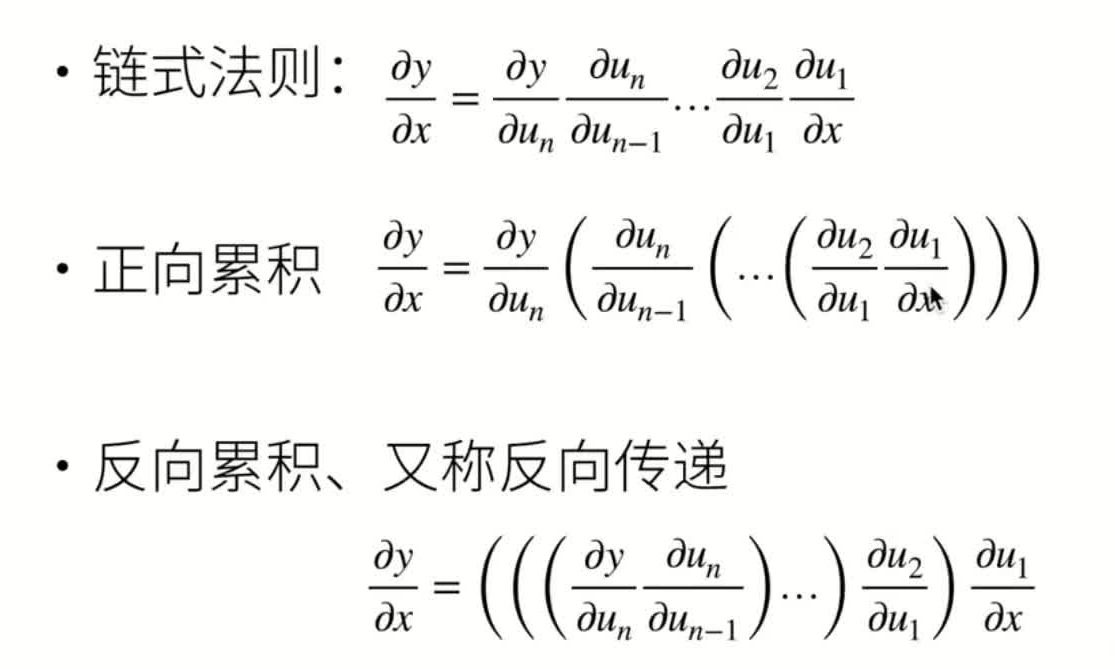

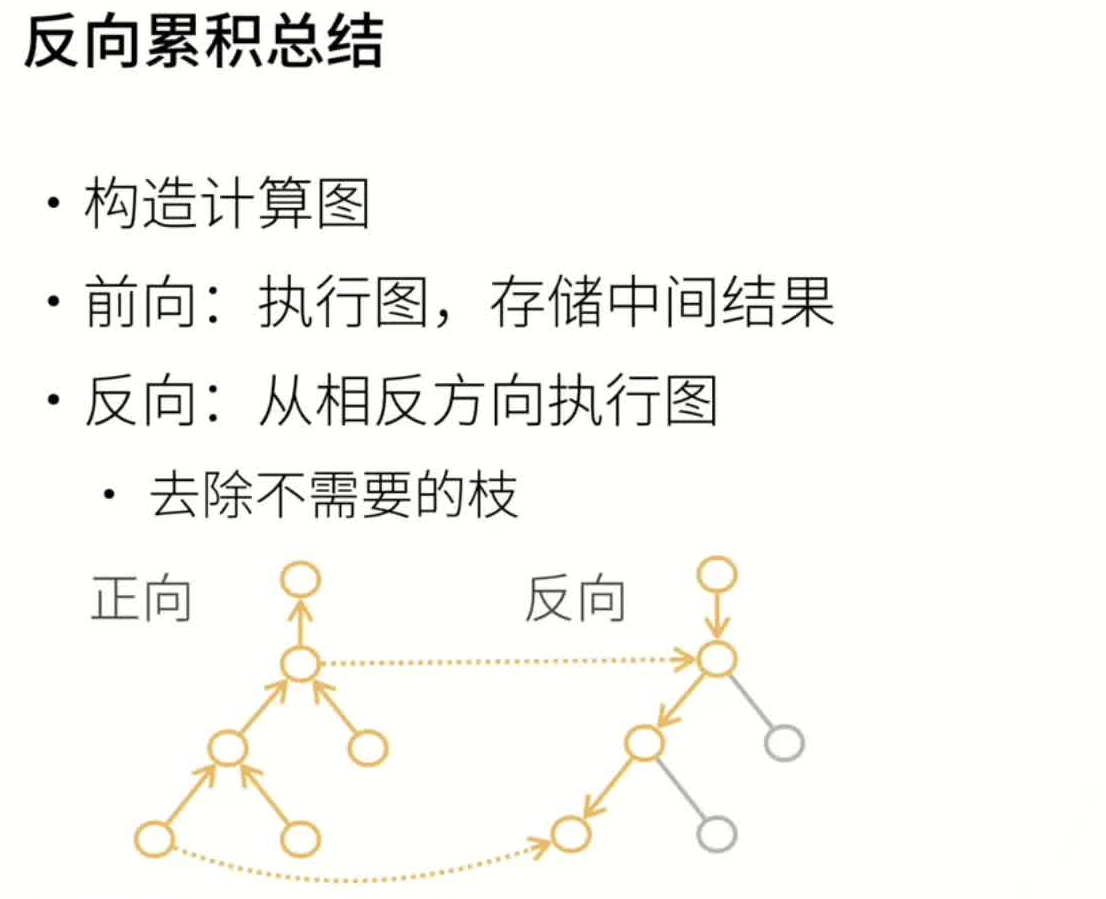

自动求导实现：

假设我们想对函数$y=2X^TX$，关于列向量X求导

In [4]:
import torch

X = torch.arange(4.0)
X

tensor([0., 1., 2., 3.])

在我们计算 y 关于 x 的梯度之前，我们需要一个地方来存储梯度

In [ ]:
# 在使用框架自动求导前，我们需要告诉系统：“请帮我盯着这个变量，记录下它都参与了什么计算，我一会要对它求导。”
X.requires_grad_(True)              # 等价于x = torch.arange(4.0, requires_grad=True)
X.grad                              # 这是一个属性，用来存储求导后的结果，初始值为None

现在我们计算 y

In [13]:
"""
    grad_fn 就是这个节点反向传播求导时的函数。<MulBackward0> 表示生成 $y$ 的最后一步操作是一个乘法（Multiplication）。
    有了这个记录，PyTorch 稍后就能利用链式法则一步步倒推求出梯度。
"""
y = 2 * torch.dot(X, X)
y

tensor(28., grad_fn=<MulBackward0>)

通过调用反向传播函数来自动计算 y 关于 x 每个分量的梯度 

In [14]:
y.backward()
X.grad

tensor([ 0.,  4.,  8., 12.])

现在让我们计算 x 的另一个函数

In [15]:
# 在默认情况下，PyTorch 会积累梯度，这对于某些应用（例如 RNN）是有用的，但在这里我们只想要这个函数的梯度，所以我们需要清除之前的梯度。
X.grad.zero_()
y = X.sum()
y.backward()
X.grad

tensor([1., 1., 1., 1.])

在深度学习中，我们的目的不是计算微分矩阵，而是批量中每个样本单独计算的偏导数之和

In [16]:
# 对非标量调用 backward 需要传入一个 gradient 参数，该参数指定了求导的方向。对于 y = x * x 来说，dy/dx = 2x，所以如果我们传入一个全是1的向量，那么我们就得到了 dy/dx 的值。
X.grad.zero_()
y = X * X
# 等价于y.backward(torch.ones(len(X)))
y.sum().backward()
X.grad

tensor([0., 2., 4., 6.])

将某些计算移动到记录的计算图之外

In [ ]:
X.grad.zero_()
y = X * X
# 将 y 变成一个与 X 无关的标量，但其数值与之前的 y 相同
u = y.detach()       # 将某些计算移动到记录的计算图之外
z = u * X

z.sum().backward()
X.grad == u

tensor([True, True, True, True])

In [18]:
X.grad.zero_()
y.sum().backward()
X.grad == 2 * X

tensor([True, True, True, True])

即使构建函数的计算图需要通过Python控制流（例如，条件、循环或任意函数调用），我们仍可以计算得到的变量的梯度

In [21]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

a.grad == d / a

tensor(True)